In [2]:
!conda install -c conda-forge matplotlib seaborn -y

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\fleur\anaconda3\envs\py312_env

  added / updated specs:
    - matplotlib
    - seaborn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |           20_gnu          51 KB  conda-forge
    brotli-1.2.0               |       h2d644bc_1          20 KB  conda-forge
    brotli-bin-1.2.0           |       hfd05255_1          22 KB  conda-forge
    cairo-1.18.4               |       h477c42c_1         1.5 MB  conda-forge
    contourpy-1.3.3            |  py312h78d62e6_4         238 KB  conda-forge
    cycler-0.12.1              |     pyhcf101f3_2          14 KB  conda-forge
    double-conversion-3.4.0    |       hac47afa_0          69 KB  conda-forge
    f



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda




Rendering Product Affinity Bar Chart...


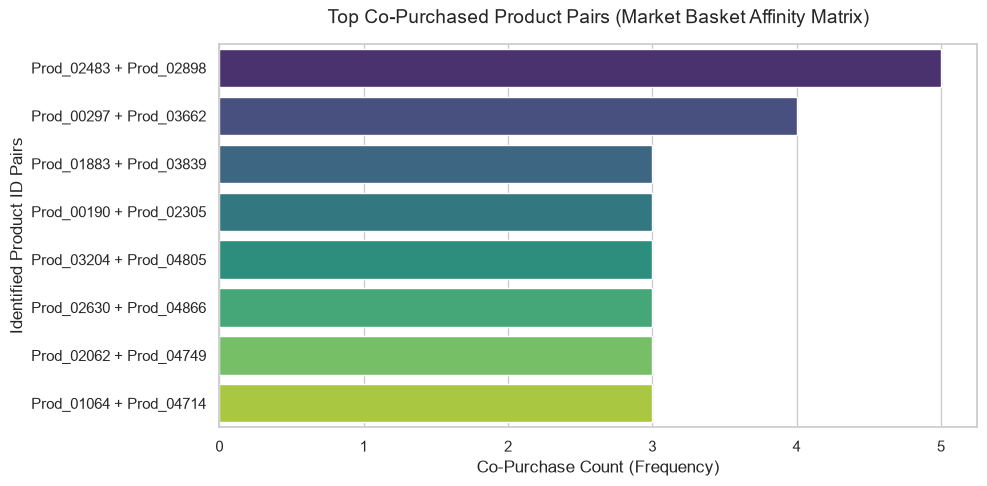


 Rendering Demographic Cross-Database Revenue Chart...


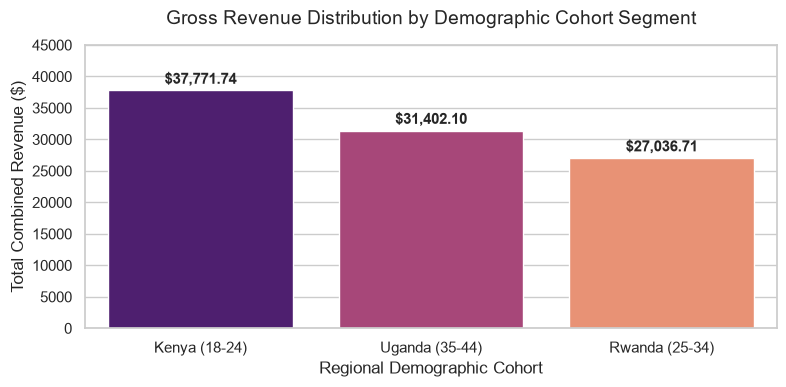


 Rendering Customer Lifetime Value vs Engagement Matrix...


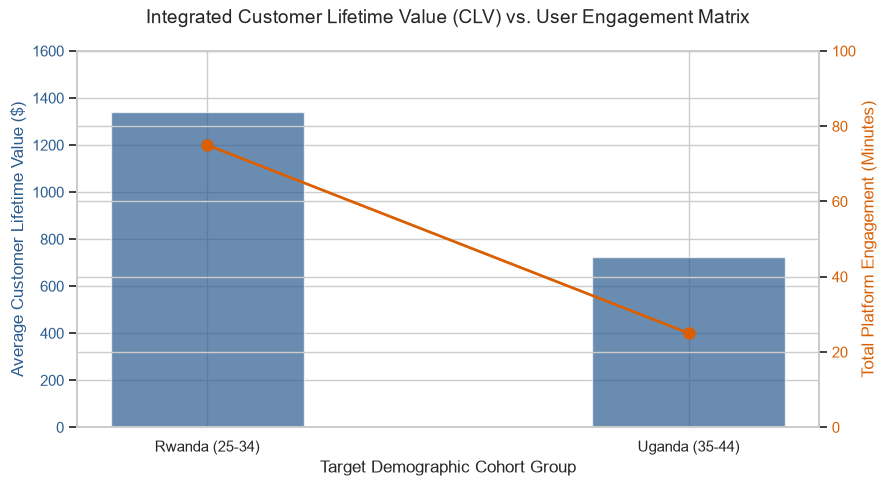

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# ---------------------------------------------------------------------------
# VISUALIZATION 1: PRODUCT AFFINITY & MARKET BASKET PAIRS MATRIX
# ---------------------------------------------------------------------------
print("Rendering Product Affinity Bar Chart...")
affinity_data = {
    "Product Pairs": [
        "Prod_02483 + Prod_02898", "Prod_00297 + Prod_03662", 
        "Prod_01883 + Prod_03839", "Prod_00190 + Prod_02305", 
        "Prod_03204 + Prod_04805", "Prod_02630 + Prod_04866", 
        "Prod_02062 + Prod_04749", "Prod_01064 + Prod_04714"
    ],
    "Purchase Frequency": [5, 4, 3, 3, 3, 3, 3, 3]
}
df_affinity = pd.DataFrame(affinity_data)

plt.figure(figsize=(10, 5))
sns.barplot(
    x="Purchase Frequency", 
    y="Product Pairs", 
    data=df_affinity, 
    palette="viridis", 
    hue="Product Pairs", 
    legend=False
)
plt.title("Top Co-Purchased Product Pairs (Market Basket Affinity Matrix)", pad=15)
plt.xlabel("Co-Purchase Count (Frequency)")
plt.ylabel("Identified Product ID Pairs")
plt.tight_layout()
plt.show() 

# ---------------------------------------------------------------------------
# VISUALIZATION 2: REVENUE DISTRIBUTION BY DEMOGRAPHIC SEGMENT
# ---------------------------------------------------------------------------
print("\n Rendering Demographic Cross-Database Revenue Chart...")
demographic_data = {
    "Region/Segment": ["Kenya (18-24)", "Uganda (35-44)", "Rwanda (25-34)"],
    "Gross Revenue ($)": [37771.74, 31402.10, 27036.71]
}
df_demo = pd.DataFrame(demographic_data)

plt.figure(figsize=(8, 4))
barplot2 = sns.barplot(
    x="Region/Segment", 
    y="Gross Revenue ($)", 
    data=df_demo, 
    palette="magma", 
    hue="Region/Segment", 
    legend=False
)

for p in barplot2.patches:
    barplot2.annotate(
        f"${p.get_height():,.2f}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 8), 
        textcoords='offset points', 
        fontweight='bold'
    )

plt.title("Gross Revenue Distribution by Demographic Cohort Segment", pad=15)
plt.xlabel("Regional Demographic Cohort")
plt.ylabel("Total Combined Revenue ($)")
plt.ylim(0, 45000)
plt.tight_layout()
plt.show()  

# ---------------------------------------------------------------------------
# VISUALIZATION 3: INTEGRATED CLV VS ENGAGEMENT CORRELATION
# ---------------------------------------------------------------------------
print("\n Rendering Customer Lifetime Value vs Engagement Matrix...")
clv_data = {
    "Cohort Group": ["Rwanda (25-34)", "Uganda (35-44)"],
    "Average CLV ($)": [1340.89, 723.38],
    "Engagement Minutes": [75.0, 25.0]
}
df_clv = pd.DataFrame(clv_data)

fig, ax1 = plt.subplots(figsize=(9, 5))

color = '#2b5c8f'
ax1.set_xlabel('Target Demographic Cohort Group')
ax1.set_ylabel('Average Customer Lifetime Value ($)', color=color)
ax1.bar(df_clv['Cohort Group'], df_clv['Average CLV ($)'], color=color, alpha=0.7, width=0.4)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 1600)

ax2 = ax1.twinx()  
color = '#d95f02'
ax2.set_ylabel('Total Platform Engagement (Minutes)', color=color)
ax2.plot(df_clv['Cohort Group'], df_clv['Engagement Minutes'], color=color, marker='o', linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 100)

plt.title("Integrated Customer Lifetime Value (CLV) vs. User Engagement Matrix", pad=20)
fig.tight_layout()
plt.show()  


